In [178]:
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[0]
sys.path.append(str(ROOT_DIR))


In [179]:
import os
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams["figure.dpi"] = 300
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams.update({
    "font.size": 15,       
    "axes.titlesize": 16,  
    "axes.labelsize": 15,  
    "xtick.labelsize": 14, 
    "ytick.labelsize": 14, 
    "legend.fontsize": 12  
})

import numpy as np
import json
import pandas as pd

from src.models.model import PeakPredictorLSTM
from src.data.pmodel_generation import (
    generate_multiple_series,
)


from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)


def recall_vs_anticipation(
    predictions,
    true_peaks,
    lookahead,
    threshold,
    burn_in=100,
):
    """
    Computes recall as a function of minimum anticipation time,
    discarding early points without valid prediction context.

    Returns:
        ks: minimum anticipation (in time steps)
        recalls: fraction of peaks anticipated at least k steps ahead
    """

    # Positions of real peaks
    peak_positions = np.where(true_peaks == 1)[0]

    # Discard peaks too close to the beginning (no valid anticipation window)
    peak_positions = peak_positions[
        peak_positions >= burn_in + lookahead
    ]

    ks = np.arange(1, lookahead + 1)
    recalls = []

    if len(peak_positions) == 0:
        return ks, np.zeros_like(ks, dtype=float)

    for k in ks:
        detected = 0

        for t_peak in peak_positions:
            t_start = t_peak - lookahead

            window = predictions[t_start:t_peak]

            # Ignore windows with NaNs (extra safety)
            if np.isnan(window).any():
                continue

            alarm_idx = np.where(window >= threshold)[0]

            if len(alarm_idx) > 0:
                t_alarm = t_start + alarm_idx[0]
                if (t_peak - t_alarm) >= k:
                    detected += 1

        recalls.append(detected / len(peak_positions))

    return ks, np.array(recalls)

def build_anticipatory_labels(peaks, lookahead):
    """
    peaks: array binário (0/1) indicando pico instantâneo
    lookahead: horizonte de previsão

    Retorna:
    y_future[t] = 1 se existir pico em [t+1, t+lookahead]
    """
    y_future = np.zeros_like(peaks)

    for t in range(len(peaks)):
        end = min(t + lookahead + 1, len(peaks))
        if np.any(peaks[t + 1 : end]):
            y_future[t] = 1

    return y_future


def evaluate_and_plot_streaming(
    models,
    df_resampled,
    df_original,
    device,
    lookahead,
    threshold=0.6,
    plot=True,
    box_cut=None,
    title="Mean intensity (top 10 pixels)",
    title_ra=None,
    path_ra=None,
    path_series=None,
    warmup=30
):

    signal_col = (
        "normalized_amplitude"
        if "normalized_amplitude" in df_resampled.columns
        else "normalized"
    )

    # séries
    series_resampled = df_resampled[signal_col].values
    series_original = df_original[signal_col].values

    series = series_resampled

    true_peaks = df_resampled["peak"].values.astype(int)
    instant_peaks = df_resampled["peak"].values.astype(int)

    true_peaks_classic_metrics = build_anticipatory_labels(
        instant_peaks,
        lookahead
    )

    predictions_dict = {}
    metrics_dict = {}

    # -----------------------------
    # INFERÊNCIA (usa resampled)
    # -----------------------------

    for name, model in models.items():

        model.eval()
        hidden = model.init_hidden()
        predictions = []

        with torch.no_grad():
            for value in series:
                x_t = torch.tensor([[[value]]], dtype=torch.float32).to(device)
                y_hat, hidden = model.step(x_t, hidden)
                predictions.append(y_hat.item())

        predictions = np.array(predictions)

        predictions = 1 / (1 + np.exp(-predictions))
        predictions[:lookahead] = np.nan

        predictions_dict[name] = predictions

        valid = (~np.isnan(predictions)) & (np.arange(len(predictions)) >= warmup)

        y_true = true_peaks_classic_metrics[valid]
        y_score = predictions[valid]
        y_pred = (y_score >= threshold).astype(int)

        metrics_dict[name] = {
            "AUC-PR": average_precision_score(y_true, y_score)
            if len(np.unique(y_true)) > 1
            else np.nan,
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "P-value": df_resampled["p_value"].iloc[0]
            if "p_value" in df_resampled.columns
            else np.nan
        }

    if plot:

        # --------------------------------------------------
        # Recall vs Anticipation
        # --------------------------------------------------

        model_styles = {
            "Endogenous": {"color": "orange", "linestyle": "--", "marker": "x"},
            "Exogenous": {"color": "green", "linestyle": "-.", "marker": "^"},
            "Exo-Endo": {"color": "purple", "linestyle": ":", "marker": "D"},
        }

        plt.figure(figsize=(8,3))

        for name, predictions in predictions_dict.items():

            ks, recalls = recall_vs_anticipation(
                predictions,
                true_peaks,
                lookahead,
                threshold=threshold,
            )

            style = model_styles.get(name, {})

            plt.plot(
                ks,
                recalls,
                linewidth=1.5,
                color=style.get("color", "black"),
                linestyle=style.get("linestyle", "-"),
                marker=style.get("marker", "o"),
                markersize=6,
                label=name
            )

        plt.xlabel("Anticipation (k)")
        plt.ylabel("Recall")
        plt.title(title_ra)
        plt.grid(alpha=0.3)
        plt.legend()

        if path_ra is not None:
            plt.savefig(path_ra, dpi=300, bbox_inches="tight")

        plt.show()

        # --------------------------------------------------
        # Série temporal
        # --------------------------------------------------

        model_colors = {
            "Endogenous": "purple",
            "Exogenous": "green",
            "Mixed": "orange"
        }

        x_ini, x_fim = box_cut

        fig, ax = plt.subplots(figsize=(9, 2.5), dpi=300)

        peak_idx = np.where(df_original["peak"].values == 1)[0]

        # eixo que mapeia resampled → escala do original
        x_resampled_mapped = np.linspace(
            0,
            len(series_original) - 1,
            len(series_resampled)
        )

        # série original
        ax.plot(
            series_original,
            lw=0.6,
            label="Mean intensity (top 10 pixels)",
            color="royalblue"
        )

        ax.plot(
            range(x_ini, x_fim+1),
            series_original[x_ini:x_fim+1],
            lw=0.9,
            color="blue"
        )

        ax.plot(
            peak_idx,
            series_original[peak_idx],
            "x",
            markersize=6,
            label="Extreme events (XE)",
            color="red"
        )

        # probabilidades (sem interpolar)
        for name, predictions in predictions_dict.items():

            color = model_colors.get(name, None)

            ax.plot(
                x_resampled_mapped,
                predictions,
                "--",
                lw=1.2,
                label=f"Probability ({name} training)",
                color=color
            )

        ax.set_title(title)

        ax.axvspan(x_ini, x_fim, color="gray", alpha=0.15)

        # inset
        # axins = inset_axes(
        #     ax,
        #     width="90%",
        #     height="90%",
        #     loc="lower center",
        #     bbox_to_anchor=(0.05, -1.3, 0.9, 0.9),
        #     bbox_transform=ax.transAxes,
        #     borderpad=0
        # )

        # axins.plot(
        #     range(x_ini, x_fim+1),
        #     series_original[x_ini:x_fim+1],
        #     lw=0.9,
        #     color="blue"
        # )

        # mask_peaks_zoom = (peak_idx >= x_ini) & (peak_idx < x_fim)
        # peak_idx_zoom = peak_idx[mask_peaks_zoom]

        # axins.plot(
        #     peak_idx_zoom,
        #     series_original[peak_idx_zoom],
        #     "x",
        #     color="red",
        #     markersize=6
        # )

        # for name, predictions in predictions_dict.items():

        #     color = model_colors.get(name, None)

        #     mask = (x_resampled_mapped >= x_ini) & (x_resampled_mapped <= x_fim)

        #     axins.plot(
        #         x_resampled_mapped[mask],
        #         predictions[mask],
        #         "--",
        #         lw=0.8,
        #         color=color
        #     )

        # axins.set_xlim(x_ini, x_fim)

        # axins.grid(alpha=0.3)
        # axins.tick_params(labelsize=12)

        # from matplotlib.patches import ConnectionPatch

        # con1 = ConnectionPatch(
        #     xyA=(x_ini, series_original[x_ini]),
        #     coordsA=ax.transData,
        #     xyB=(x_ini, axins.get_ylim()[1]),
        #     coordsB=axins.transData,
        #     color="0.5",
        #     lw=0.8,
        #     linestyle="--"
        # )

        # con2 = ConnectionPatch(
        #     xyA=(x_fim, series_original[x_fim-1]),
        #     coordsA=ax.transData,
        #     xyB=(x_fim, axins.get_ylim()[1]),
        #     coordsB=axins.transData,
        #     color="0.5",
        #     lw=0.8,
        #     linestyle="--"
        # )

        # ax.add_artist(con1)
        # ax.add_artist(con2)

        ax.legend(loc="upper left", frameon=True)

        ax.grid(alpha=0.3)
        ax.set_xlabel("Time steps")
        ax.set_ylabel("Normalized amplitude\nProbability")

        plt.tight_layout()

        if path_series is not None:
            plt.savefig(path_series, dpi=300, bbox_inches="tight")

        plt.show()

    return metrics_dict, predictions_dict

def load_and_prepare_csv(file_path, peak_percentile):
    """
    Loads a real CSV time series and generates peak labels using a percentile.
    """
    print(f"\nLoading file: {os.path.basename(file_path)}")

    df = pd.read_csv(file_path)
    df.columns = ["time", "amplitude"]

    amp = df["amplitude"].values
    df["normalized_amplitude"] = (
        (amp - amp.min()) / (amp.max() - amp.min() + 1e-6)
        if amp.max() > amp.min()
        else np.zeros_like(amp)
    )

    threshold = np.percentile(
        df["normalized_amplitude"], peak_percentile
    )
    df["peak"] = (df["normalized_amplitude"] > threshold).astype(int)
    df["peak_threshold"] = threshold

    return df

In [180]:
np.random.seed(30)

with open("../config/config_endo.json", "r") as f:
    config_endo = json.load(f)

with open("../config/config_exo.json", "r") as f:
    config_exo = json.load(f)

with open("../config/config_exo_endo.json", "r") as f:
    config_exo_endo = json.load(f)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


In [181]:
# ---------- Model ----------
model_endo = PeakPredictorLSTM(config_endo["model"]).to(device)
model_endo.load_state_dict(
    torch.load("../results/best_model_endo.pth", map_location=device)
)

model_exo = PeakPredictorLSTM(config_exo["model"]).to(device)
model_exo.load_state_dict(
    torch.load("../results/best_model_exo.pth", map_location=device)
)

model_exo_endo = PeakPredictorLSTM(config_exo_endo["model"]).to(device)
model_exo_endo.load_state_dict(
    torch.load("../results/best_model_exo_endo.pth", map_location=device)
)

<All keys matched successfully>

In [182]:
import pandas as pd

heat_flux_resampled = pd.read_csv("./data/jorek/heat_flux_iter_resampled.csv")
heat_flux = pd.read_csv("./data/jorek/heat_flux_iter.csv")

raw_series = heat_flux_resampled["Amplitude"]

p1 = np.percentile(raw_series, 5)   # limite inferior (1%)
p = np.percentile(raw_series, 100) # limite superior (opcional)

heat_flux_resampled["normalized"] = (raw_series - p1) / (p - p1 + 1e-6)

threshold = np.percentile(heat_flux_resampled["normalized"], 99)
heat_flux_resampled["peak"] = (heat_flux_resampled["normalized"] > threshold).astype(int)
heat_flux_resampled["peak_threshold"] = threshold

raw_series = heat_flux["Amplitude"]

p1 = np.percentile(raw_series, 5)   # limite inferior (1%)
p = np.percentile(raw_series, 100) # limite superior (opcional)

heat_flux["normalized"] = (raw_series - p1) / (p - p1 + 1e-6)

threshold = np.percentile(heat_flux["normalized"], 99)
heat_flux["peak"] = (heat_flux["normalized"] > threshold).astype(int)
heat_flux["peak_threshold"] = threshold

print(heat_flux.head())

print(heat_flux_resampled.head())



solar_series_resampled = pd.read_csv("./data/sdo/sun_lightcurve.csv")

raw_series = solar_series_resampled["Amplitude"]

solar_series_resampled["normalized"] = (
    (raw_series - np.min(raw_series)) /
    (np.max(raw_series) - np.min(raw_series) + 1e-6)
)

threshold = np.percentile(solar_series_resampled["normalized"], 95)
solar_series_resampled["peak"] = (solar_series_resampled["normalized"] > threshold).astype(int)
solar_series_resampled["peak_threshold"] = threshold

idx_min = solar_series_resampled["normalized"].idxmin()
prev_val = solar_series_resampled["normalized"].iloc[idx_min - 1]
next_val = solar_series_resampled["normalized"].iloc[idx_min + 1]
solar_series_resampled.loc[idx_min, "normalized"] = (prev_val + next_val) / 2

print(solar_series_resampled.head())

solar_series = pd.read_csv("./data/sdo/sun_lightcurve.csv")

raw_series = solar_series["Amplitude"]

solar_series["normalized"] = (
    (raw_series - np.min(raw_series)) /
    (np.max(raw_series) - np.min(raw_series) + 1e-6)
)

threshold = np.percentile(solar_series["normalized"], 95)
solar_series["peak"] = (solar_series["normalized"] > threshold).astype(int)
solar_series["peak_threshold"] = threshold

print(solar_series.head())

   Time-step  Amplitude  normalized  peak  peak_threshold
0          0   0.000573   -0.133764     0        0.583436
1          1   0.759309   -0.057360     0        0.583436
2          2   1.412255    0.008392     0        0.583436
3          3   0.800641   -0.053198     0        0.583436
4          4   1.455755    0.012772     0        0.583436
   Time-step  Amplitude  normalized  peak  peak_threshold
0        0.0   0.000000   -0.133764     0        0.583435
1        1.0   0.067390   -0.057360     0        0.583435
2        2.0   0.125384    0.008392     0        0.583435
3        3.0   0.071061   -0.053198     0        0.583435
4        4.0   0.129247    0.012772     0        0.583435
  Time-step  Amplitude  normalized  peak  peak_threshold
0     00:08   0.364134    0.364134     0        0.925152
1     00:18   0.361608    0.361608     0        0.925152
2     00:27   0.361187    0.361187     0        0.925152
3     00:37   0.344980    0.344980     0        0.925152
4     00:47   0.371

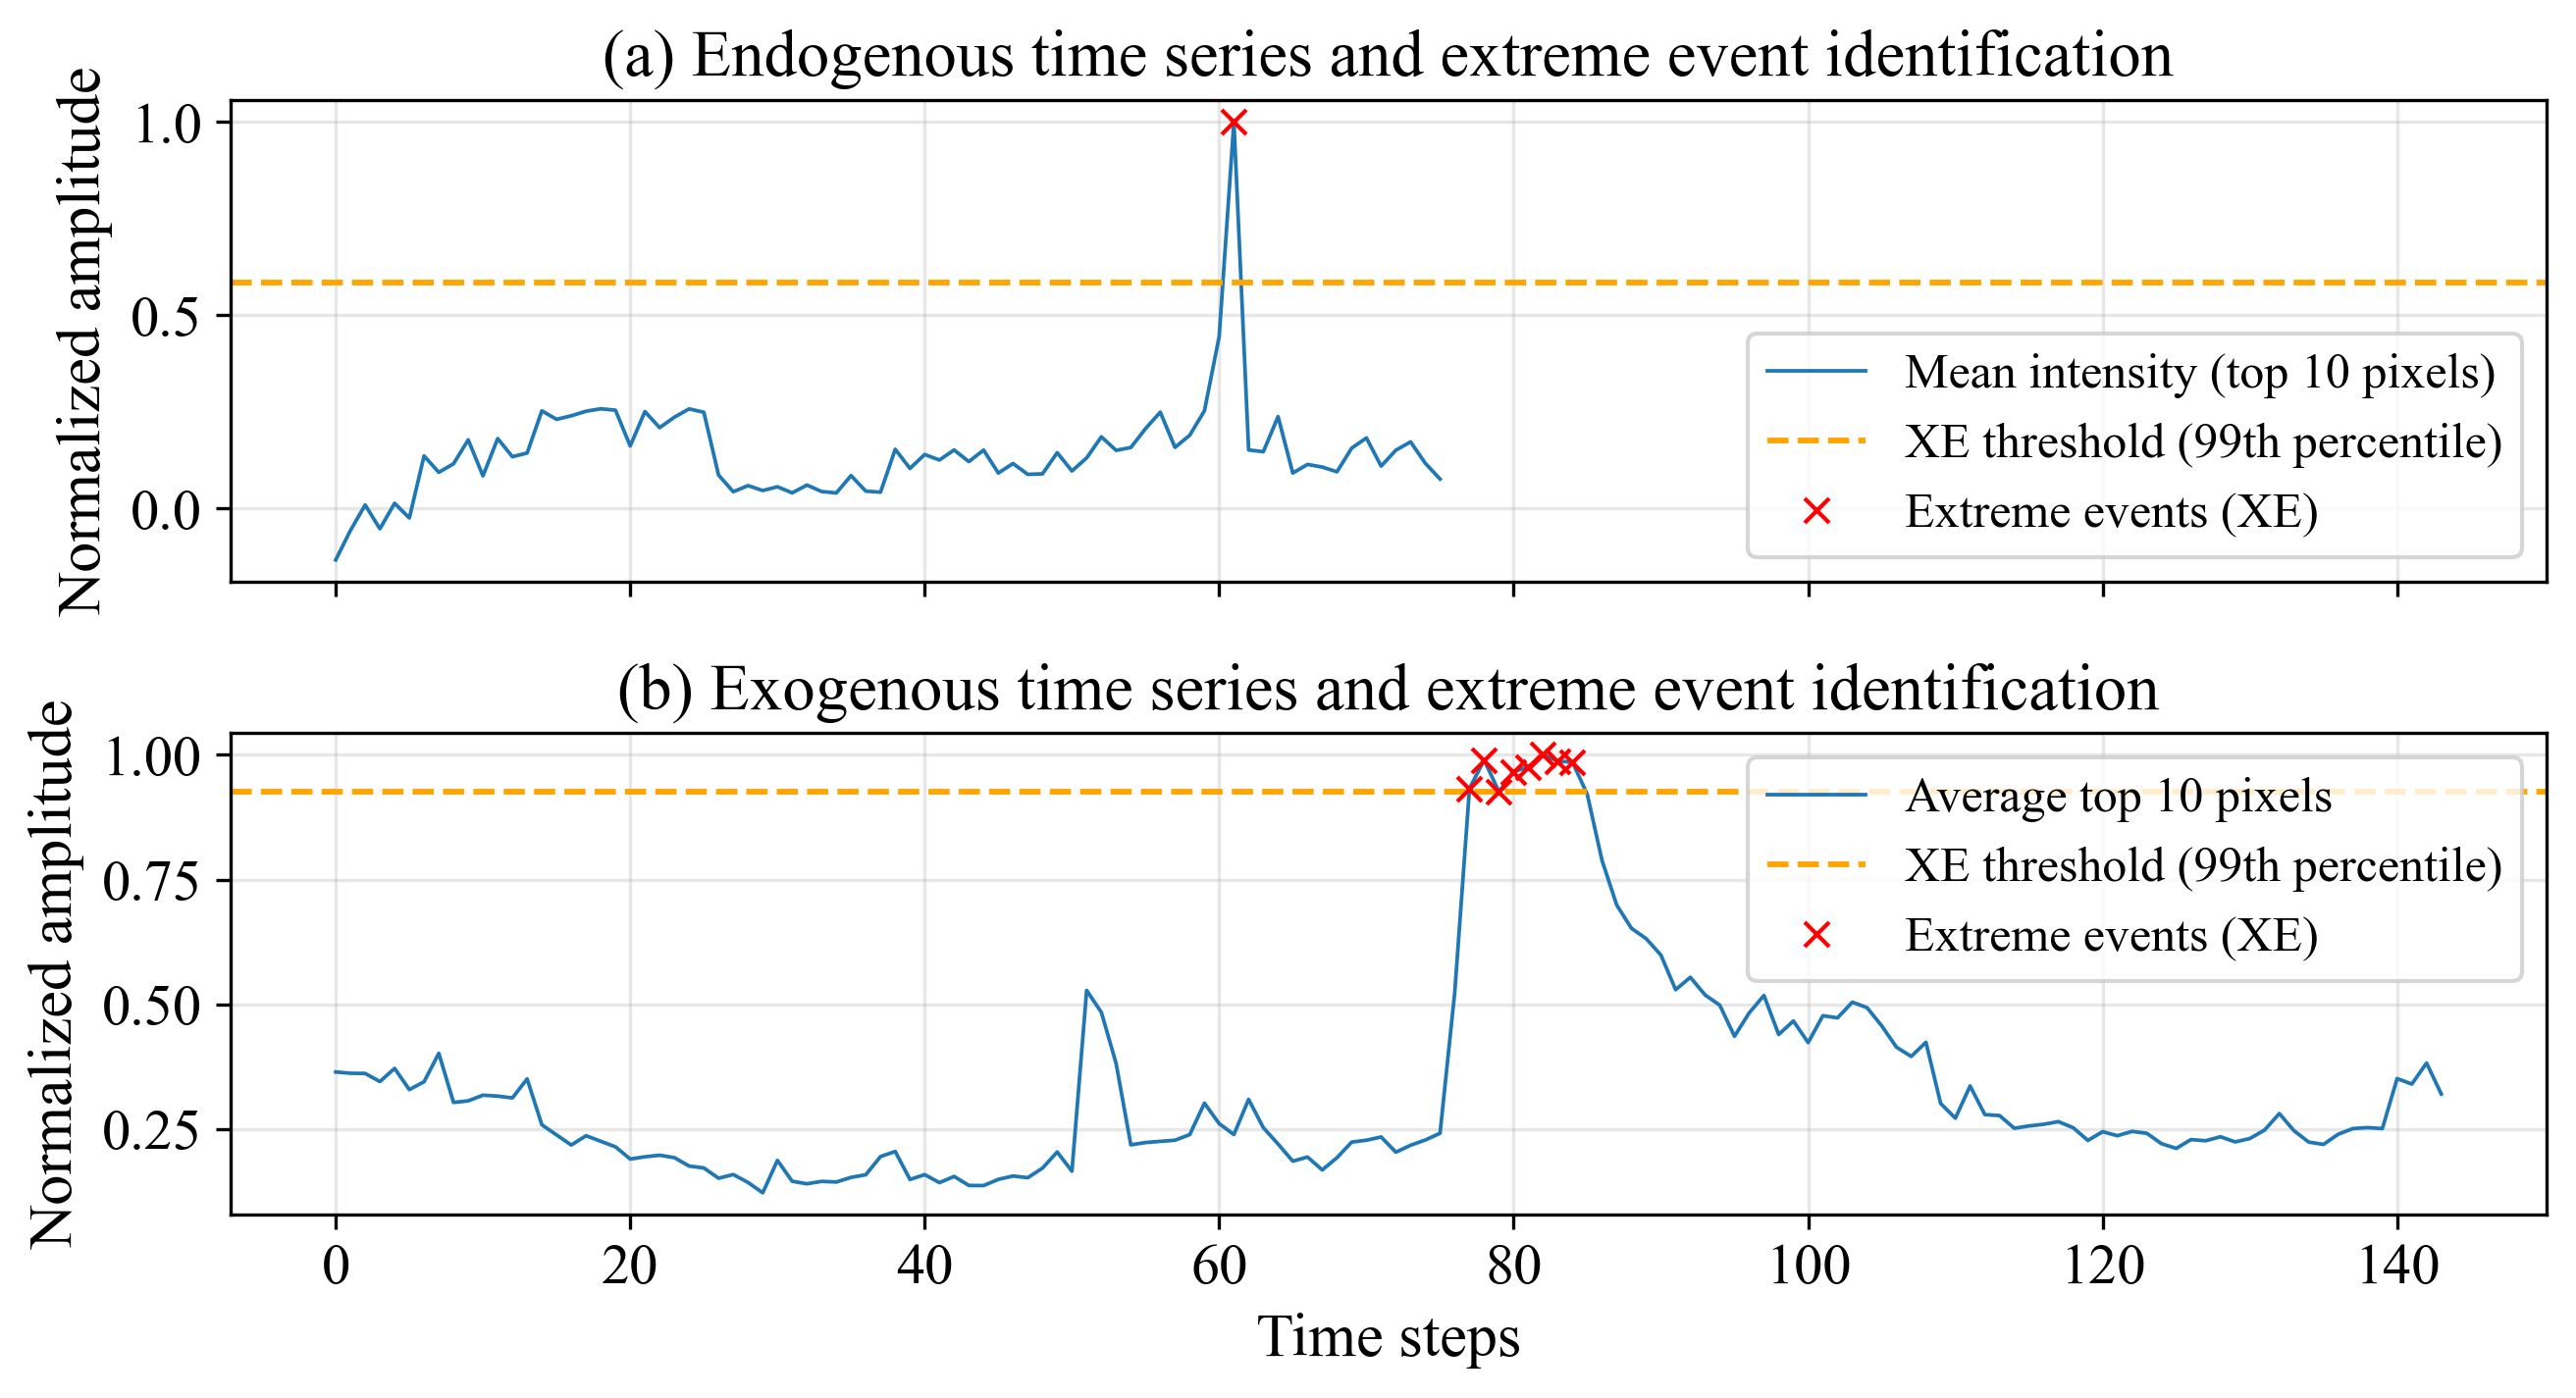

In [183]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

# ---------- Endogenous ----------
t_endo = np.arange(len(heat_flux_resampled))
theta_endo = heat_flux_resampled["peak_threshold"].iloc[0]

axes[0].plot(
    t_endo,
    heat_flux_resampled["normalized"],
    lw=0.9,
    label="Mean intensity (top 10 pixels)"
)

# Threshold line
axes[0].axhline(
    theta_endo,
    linestyle="--",
    linewidth=1.4,
    label="XE threshold (99th percentile)",
    color="orange"
)

# Peaks
axes[0].plot(
    t_endo[heat_flux_resampled["peak"] == 1],
    heat_flux_resampled.loc[heat_flux_resampled["peak"] == 1, "normalized"],
    "x",
    markersize=6,
    label="Extreme events (XE)",
    color="red"
)

axes[0].set_ylabel("Normalized amplitude")
axes[0].set_title("(a) Endogenous time series and extreme event identification")
axes[0].grid(alpha=0.3)
axes[0].legend(frameon=True)

# ---------- Exogenous ----------
t_exo = np.arange(len(solar_series_resampled))
theta_exo = solar_series_resampled["peak_threshold"].iloc[0]

axes[1].plot(
    t_exo,
    solar_series_resampled["normalized"],
    lw=0.9,
    label="Average top 10 pixels"
)

# Threshold line
axes[1].axhline(
    theta_exo,
    linestyle="--",
    linewidth=1.4,
    label="XE threshold (99th percentile)",
    color="orange"
)

# Peaks
axes[1].plot(
    t_exo[solar_series_resampled["peak"] == 1],
    solar_series_resampled.loc[solar_series_resampled["peak"] == 1, "normalized"],
    "x",
    markersize=6,
    label="Extreme events (XE)",
    color="red"
)

axes[1].set_xlabel("Time steps")
axes[1].set_ylabel("Normalized amplitude")
axes[1].set_title("(b) Exogenous time series and extreme event identification")
axes[1].grid(alpha=0.3)
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()



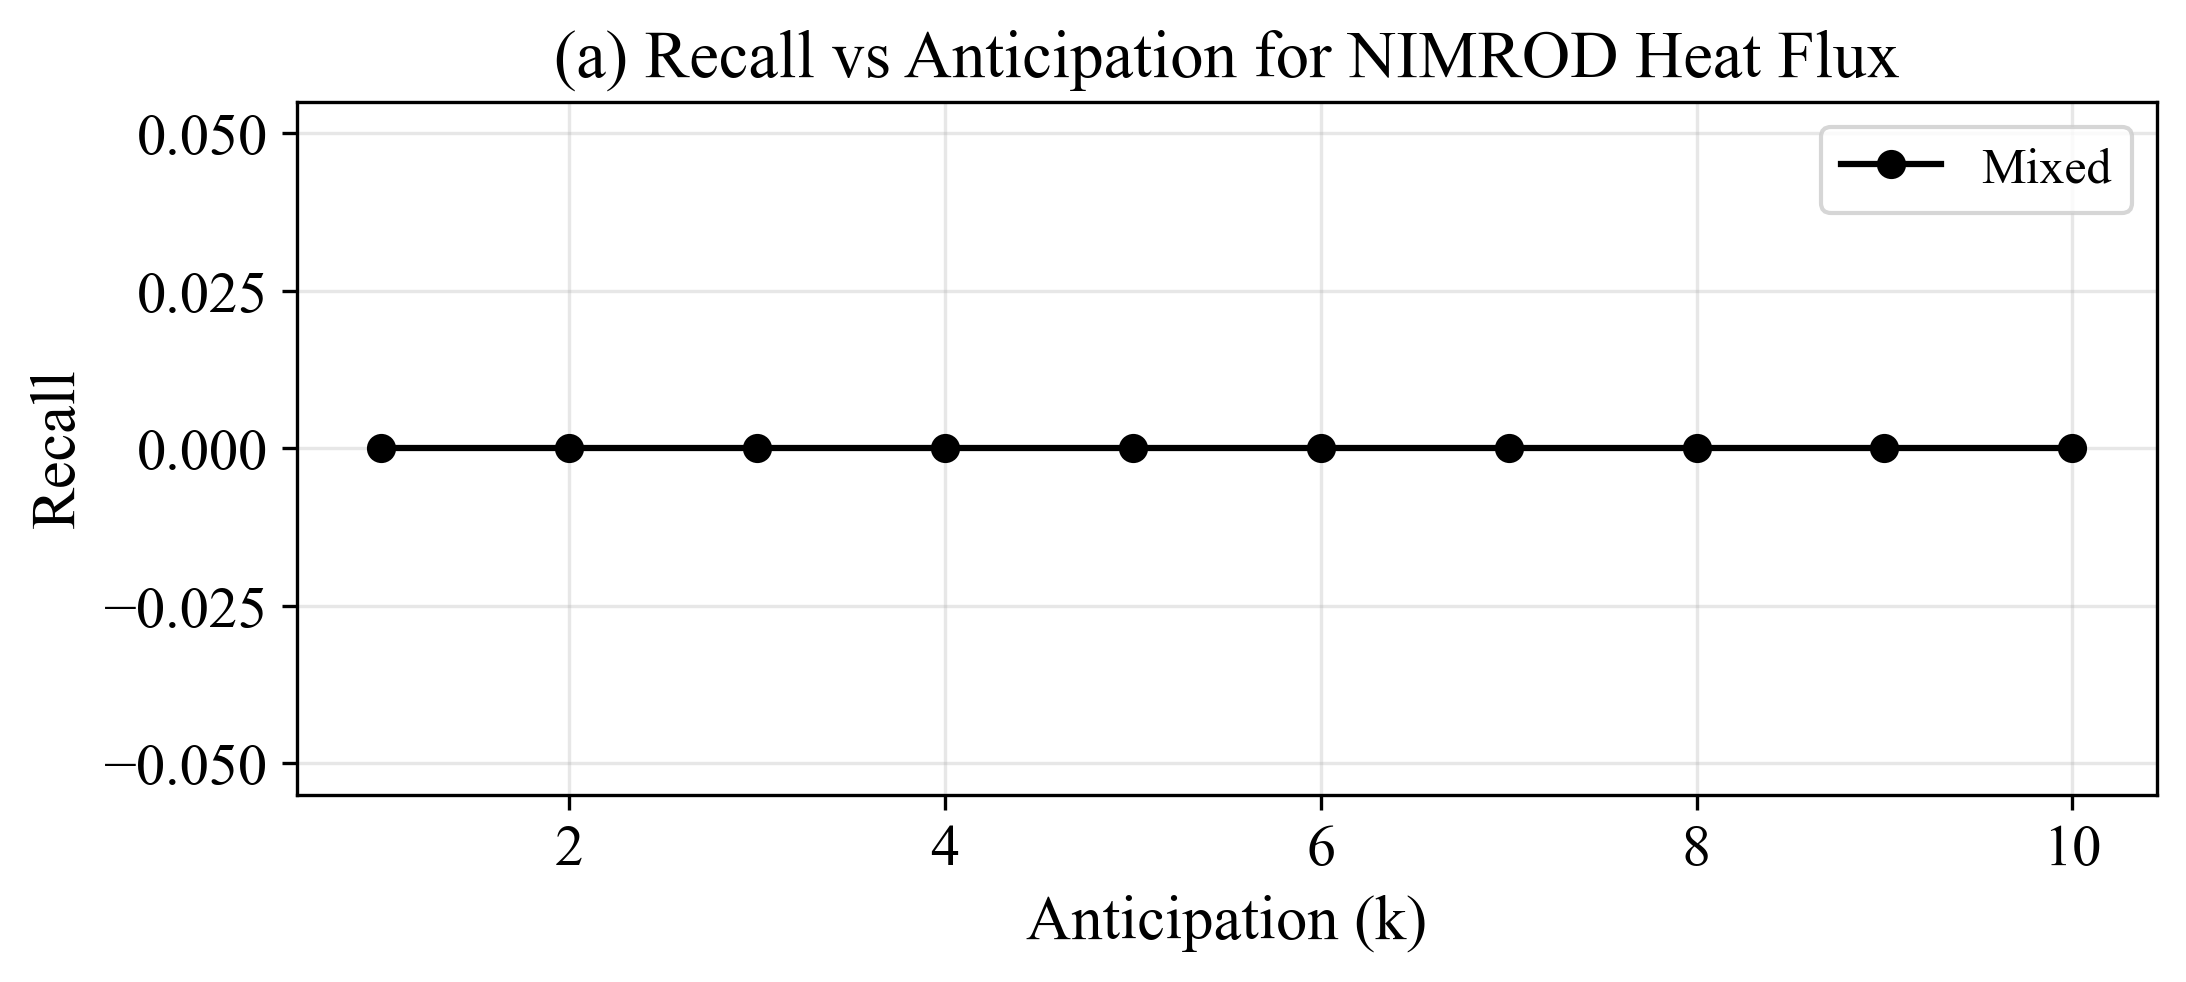

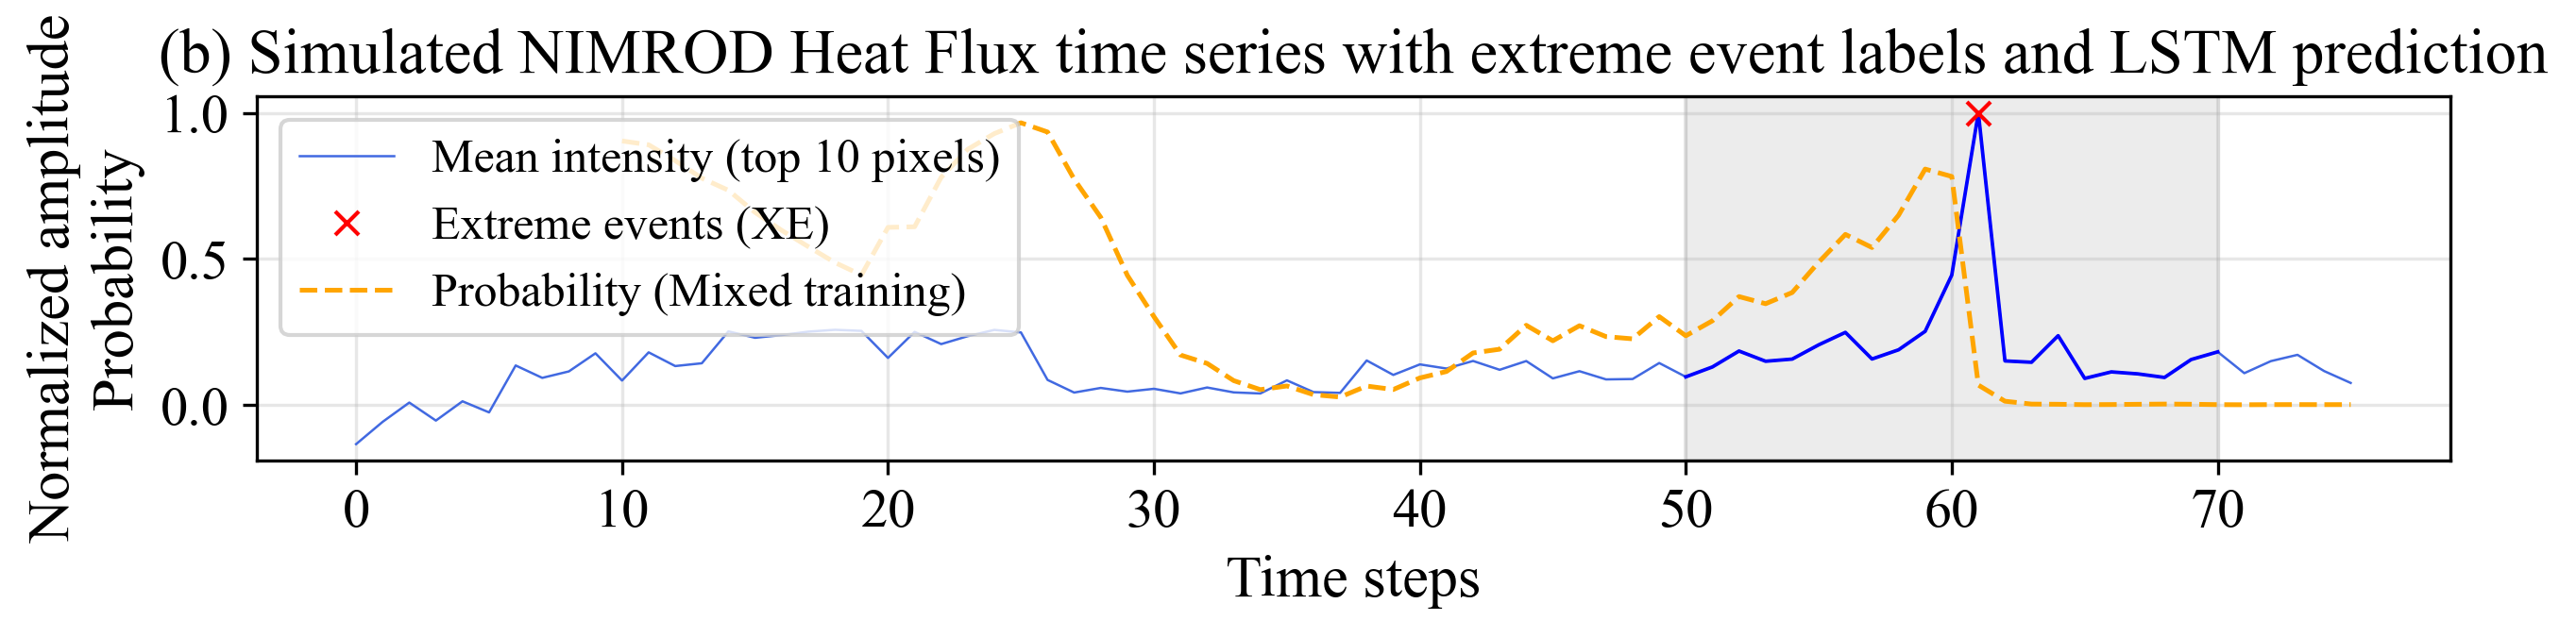

{'Mixed': {'AUC-PR': 0.9833333333333333, 'Precision': 1.0, 'Recall': 0.3, 'F1': 0.46153846153846156, 'P-value': nan}}


In [184]:
models = {
    "Mixed": model_exo_endo
}
metrics, predictions = evaluate_and_plot_streaming(
    models,
    heat_flux_resampled,
    heat_flux,
    device,
    lookahead=config_exo["data"]["lookahead"],
    plot=True,
    title="(b) Simulated NIMROD Heat Flux time series with extreme event labels and LSTM prediction",
    title_ra="(a) Recall vs Anticipation for NIMROD Heat Flux",
    box_cut=(50, 70),
    path_series = "../paper/images/nimrod_time_series_with_lstm_prediction_mixed.png"
)

print(metrics)



Average intensity of the 10 brightest pixels in an SDO/AIA 304 Å

Average intensity of the 10 brightest pixels (AIA 304 Å)

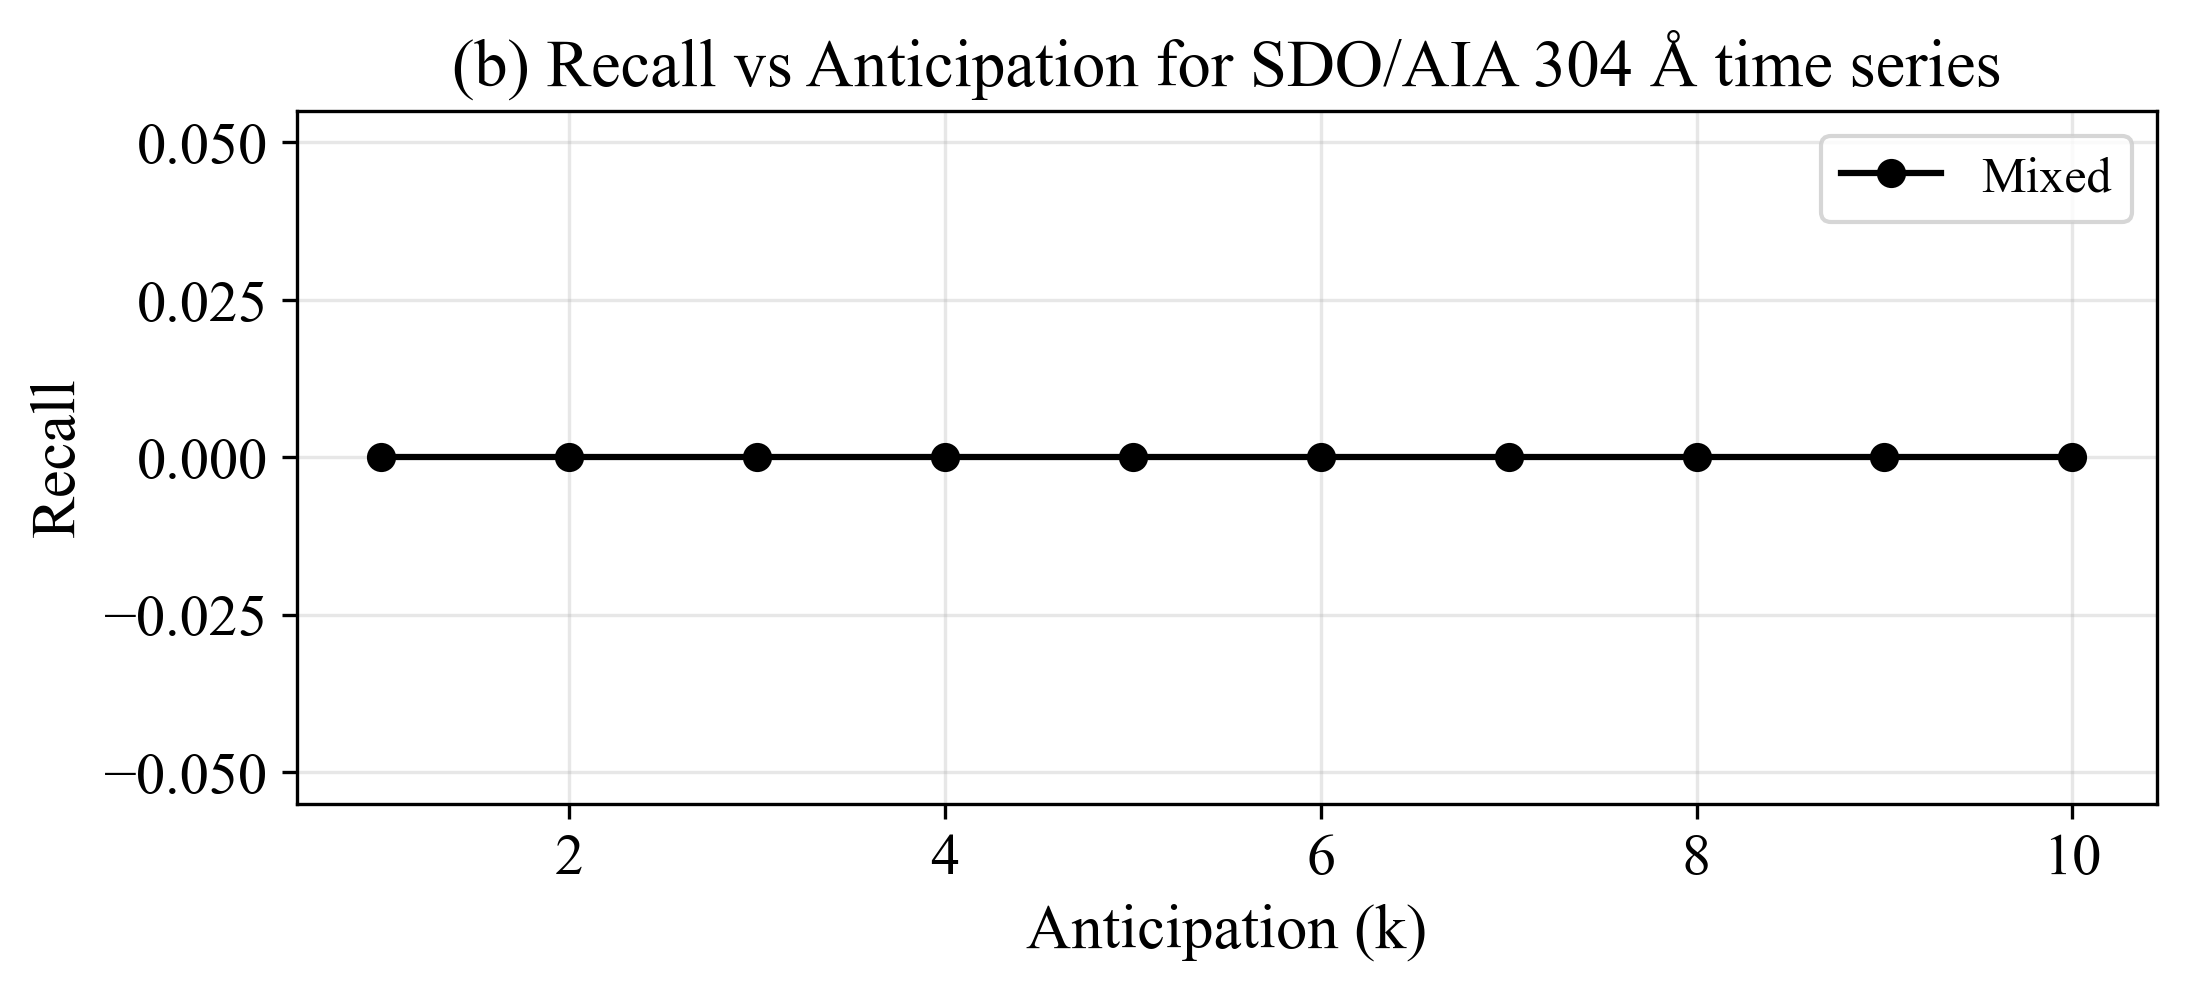

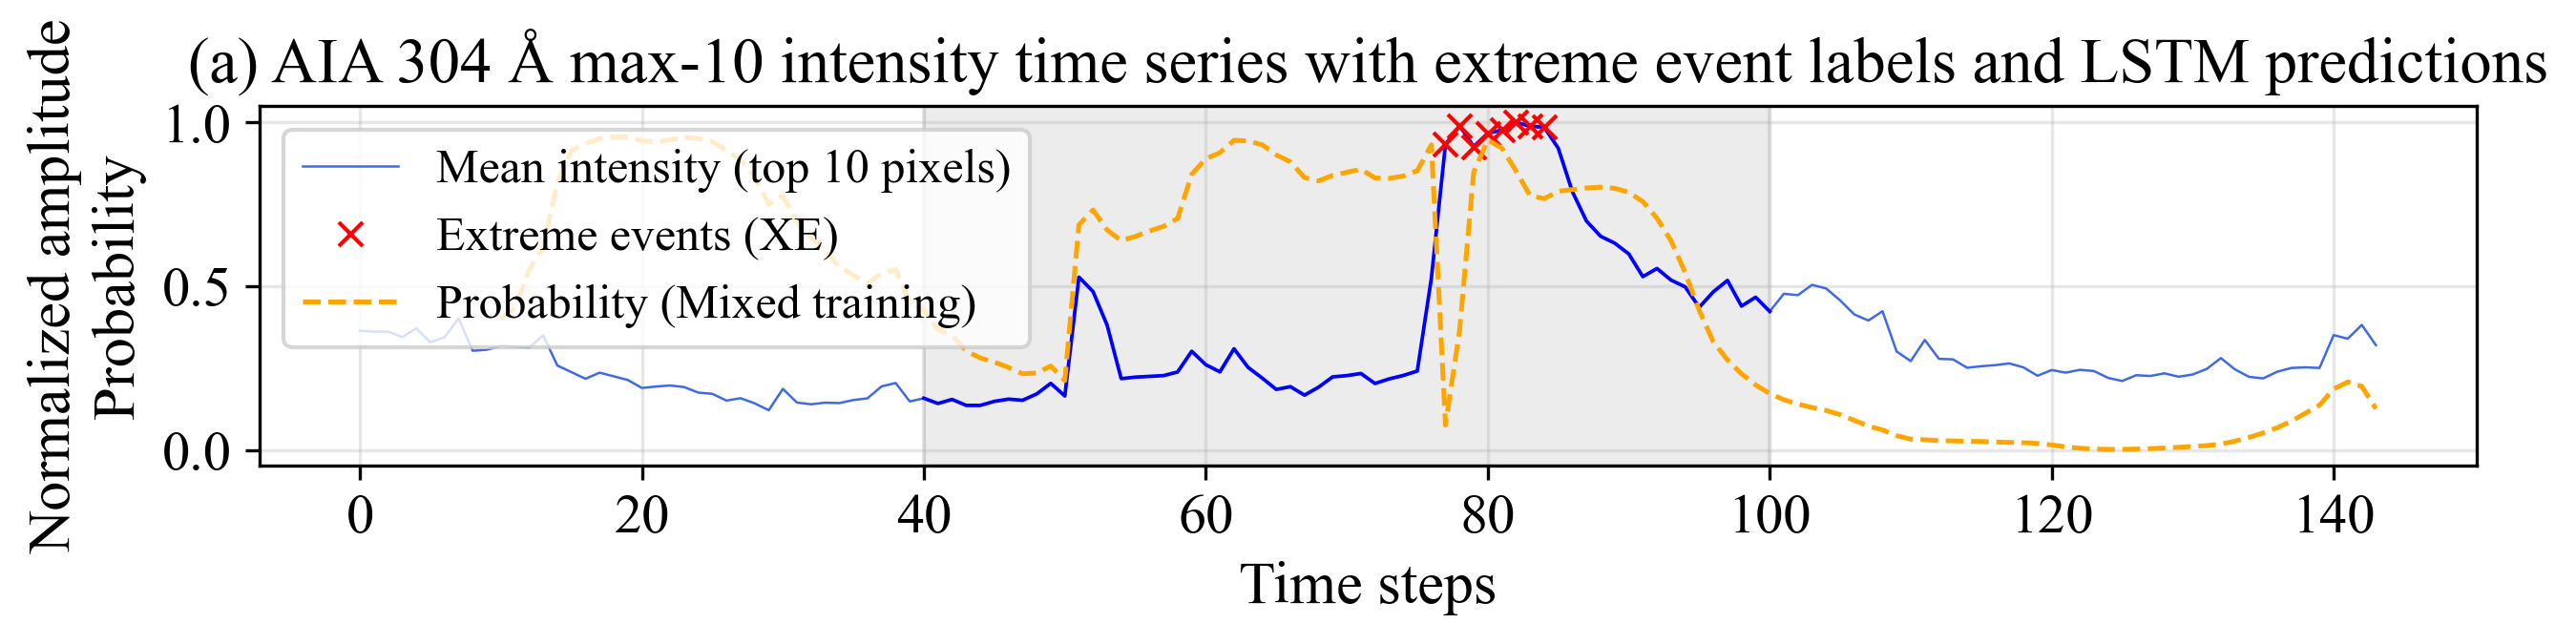

{'Mixed': {'AUC-PR': 0.5117551403925973, 'Precision': 0.3333333333333333, 'Recall': 0.8823529411764706, 'F1': 0.4838709677419355, 'P-value': nan}}


In [186]:
models = {
    "Mixed": model_exo_endo
}
metrics, predictions = evaluate_and_plot_streaming(
    models,
    solar_series_resampled,
    solar_series_resampled,
    device,
    lookahead=config_exo["data"]["lookahead"],
    plot=True,
    title="(a) AIA 304 Å max-10 intensity time series with extreme event labels and LSTM predictions",
    title_ra="(b) Recall vs Anticipation for SDO/AIA 304 Å time series",
    box_cut=(40, 100),
    path_series = "../paper/images/sdo_time_series_with_lstm_prediction_mixed.png"
)

print(metrics)

